<a href="https://colab.research.google.com/github/pmatkowska94/MSC_Data_Science/blob/main/Pilot_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Pilot_for_Python_5_Processes.csv to Pilot_for_Python_5_Processes.csv


In [ ]:
df = pd.read_csv('Pilot_for_Python_5_Processes.csv')
df.head()

,Vessel,Process_ID,Run_ID,Clone_ID,time [day],VCD [10 ^6 cells/mL],Volume [L],Agitation [rpm],P/V [W/m3 ],VVM (air/max_vol),kLa [1/h],impeller_diameter [cm],Tip speed [m/s],Aspect_ratio,DO [%],Reynolds
0,ambr 15,1,1,1,0.0,0.41,15.0,1200.0,220.8,0.0,NaN,NaN,NaN,NaN,NaN,NaN
1,ambr 15,1,1,1,1.0,2.67,15.0,1200.0,220.8,0.0,NaN,NaN,NaN,NaN,NaN,NaN
2,ambr 15,1,1,1,2.0,4.88,15.0,1200.0,220.8,0.0,NaN,NaN,NaN,NaN,NaN,NaN
3,ambr 15,1,1,1,3.0,7.09,15.0,1200.0,220.8,0.0,NaN,NaN,NaN,NaN,NaN,NaN
4,ambr 15,1,1,1,4.0,11.16,15.0,1200.0,220.8,0.0,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df.rename(columns={
    'Vessel': 'vessel',
    'Process_ID': 'p_id',
    'Run_ID' : 'r_id',
    'Clone_ID': 'clone_id',
    'time [day]': 'time',
    'VCD [10 ^6 cells/mL]': 'vcd',
    'Volume [L]': 'volume',
    'Agitation [rpm]': 'agitation',
    'P/V [W/m3 ]': 'p_v',
    'VVM (air/max_vol)': 'vvm',
    'kLa [1/h]': 'kla',
    'impeller_diameter [cm]': 'impeller_d',
    'Tip speed [m/s]': 'tip_speed',
    'Aspect_ratio': 'aspect_r',
    'DO [%]': 'do',
    'Reynolds': 'reynolds'
}, inplace=True)

In [ ]:
df.head()

,vessel,p_id,r_id,clone_id,time,vcd,volume,agitation,p_v,vvm,kla,impeller_d,tip_speed,aspect_r,do,reynolds
0,ambr 15,1,1,1,0.0,0.41,15.0,1200.0,220.8,0.0,NaN,NaN,NaN,NaN,NaN,NaN
1,ambr 15,1,1,1,1.0,2.67,15.0,1200.0,220.8,0.0,NaN,NaN,NaN,NaN,NaN,NaN
2,ambr 15,1,1,1,2.0,4.88,15.0,1200.0,220.8,0.0,NaN,NaN,NaN,NaN,NaN,NaN
3,ambr 15,1,1,1,3.0,7.09,15.0,1200.0,220.8,0.0,NaN,NaN,NaN,NaN,NaN,NaN
4,ambr 15,1,1,1,4.0,11.16,15.0,1200.0,220.8,0.0,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 663 entries, 0 to 662
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   vessel      663 non-null    object 
 1   p_id        663 non-null    int64  
 2   r_id        663 non-null    int64  
 3   clone_id    663 non-null    int64  
 4   time        634 non-null    float64
 5   vcd         616 non-null    float64
 6   volume      616 non-null    float64
 7   agitation   616 non-null    float64
 8   p_v         616 non-null    float64
 9   vvm         509 non-null    float64
 10  kla         295 non-null    float64
 11  impeller_d  602 non-null    float64
 12  tip_speed   602 non-null    float64
 13  aspect_r    492 non-null    float64
 14  do          546 non-null    float64
 15  reynolds    602 non-null    float64
dtypes: float64(12), int64(3), object(1)
memory usage: 83.0+ KB


All importnat variables are float. Categorical are int. Vessel describes name of the vessel, which is not importnat.

There are some missing values. kla represents the most NaN

In [ ]:
df.describe()

,p_id,r_id,clone_id,time,vcd,volume,agitation,p_v,vvm,kla,impeller_d,tip_speed,aspect_r,do,reynolds
count,663.000000,663.000000,663.000000,634.000000,616.000000,616.000000,616.000000,616.000000,509.000000,295.000000,602.000000,602.000000,492.000000,546.000000,602.000000
mean,3.340875,1.155354,5.586727,7.013982,9.985259,343.958490,235.241883,36.866039,0.016291,3.298644,20.121229,0.993992,1.903699,42.820513,114574.869452
std,1.240652,0.468007,3.517063,4.308190,6.561348,637.764007,239.434079,45.511836,0.015851,2.643333,22.490926,0.446406,0.238773,6.967343,157180.040211
min,1.000000,1.000000,1.000000,-0.060700,0.290000,0.015000,30.000000,8.000000,0.000000,0.900000,1.100000,0.408000,1.440000,40.000000,3638.000000
25%,3.000000,1.000000,3.000000,3.000000,4.700000,2.000000,97.000000,13.380000,0.008000,1.000000,5.400000,0.570000,1.800000,40.000000,13910.000000
50%,4.000000,1.000000,5.000000,7.000000,9.340580,5.000000,162.000000,29.600000,0.010000,2.400000,7.000000,0.950000,2.000000,40.000000,29957.820000
75%,4.000000,1.000000,8.000000,10.968800,14.380000,500.000000,260.000000,33.000000,0.023500,3.700000,25.060000,1.254000,2.000000,40.000000,185558.300000
max,5.000000,3.000000,12.000000,14.094200,27.272727,2000.000000,1200.000000,220.800000,0.070000,8.000000,89.760000,2.170000,2.500000,60.000000,762006.050000


There are 5 scale up processes using 12 CHO cell clones.

Processes start at D0 and ens at D14.

STRs are represented by volume between 15mL and 2000L.
Max agitation is 1200 which is outlier or defined for the smallest STR (15mL)

kla has the most NaN, followed by aspect ratio, VVM and DO.

One process with Reynolds 3638 (laminar flow) does not represent a real porcess condition.

In [ ]:
df.duplicated().sum()

np.int64(11)

In [ ]:
df.nunique()

,0
vessel,23
p_id,5
r_id,3
clone_id,12
time,365
vcd,467
volume,14
agitation,25
p_v,23
vvm,13


There are 14 different scales (14x different volume), 5 processes, 12 clones, 23 vessels (providers/scales).

In [ ]:
df.isnull().sum()

,0
vessel,0
p_id,0
r_id,0
clone_id,0
time,29
vcd,47
volume,47
agitation,47
p_v,47
vvm,154


<Axes: >

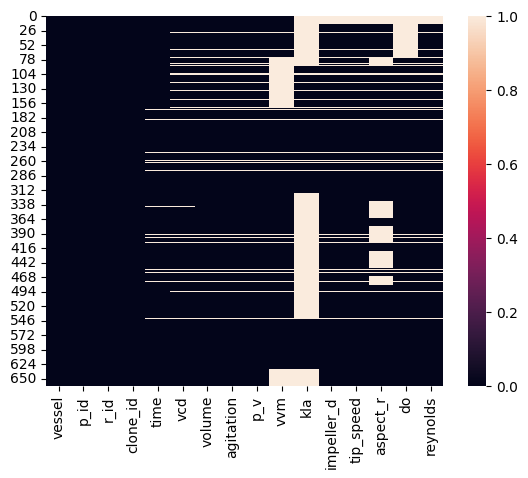

In [ ]:
sns.heatmap(df.isnull())

kla is missing in >50% columns. Drop for training.

DO as it vary between 40% and 60% and is a stable process condition could be drop for training.

VVM (important shear stress feture) can be imputed as it varies between 0.0 and 0.07 (which is not high in bioprocessing).


Aspect ratio could be imputed based on the process, as this is mostly constant during scale up asross different vessels.

<Axes: xlabel='clone_id', ylabel='count'>

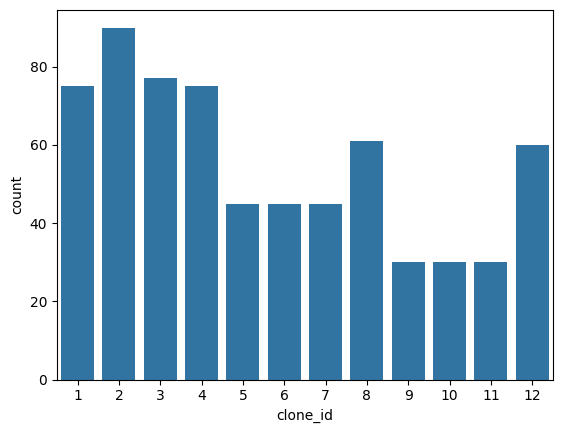

In [ ]:
sns.countplot(x='clone_id', data=df)


There are some clones that were used for longer scale up process, but data shows that each clone was used for at least 2 scales (2x ~14 days)

<Axes: xlabel='p_id', ylabel='count'>

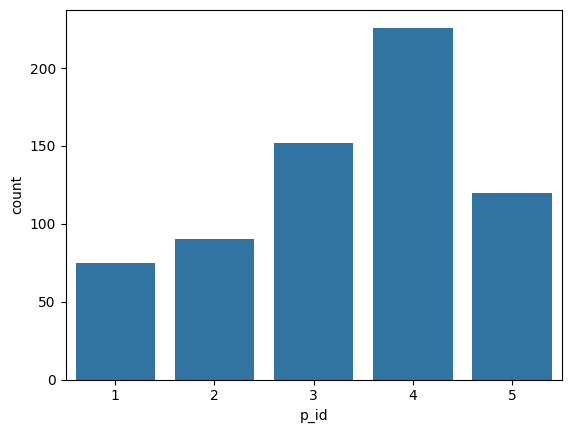

In [ ]:
sns.countplot(x='p_id', data=df)

Process 4 is the longest scale uip process, which means that there were use the most different vessels or clones/process conditions. This is followed by Process Nr 3.

In [ ]:
pd.crosstab(df['p_id'], df['clone_id'])


clone_id,1,2,3,4,5,6,7,8,9,10,11,12
p_id,,,,,,,,,,,,
1,75,0,0,0,0,0,0,0,0,0,0,0
2,0,90,0,0,0,0,0,0,0,0,0,0
3,0,0,77,75,0,0,0,0,0,0,0,0
4,0,0,0,0,45,45,45,61,30,0,0,0
5,0,0,0,0,0,0,0,0,0,30,30,60


P1 and P2 was used only one cell line each.
P3 has 2 clones.
P4 has the most clones: 5.
P5 has 3 clones.

In [ ]:
pd.crosstab(df['p_id'], df['volume'])

volume,0.015,0.250,2.000,2.700,3.000,5.000,10.000,15.000,50.000,200.000,250.000,500.000,1000.000,2000.000
p_id,,,,,,,,,,,,,,
1,0,0,0,0,0,0,14,14,14,14,0,0,14,0
2,12,13,0,0,0,13,0,0,13,13,0,0,0,13
3,0,78,0,0,0,29,0,0,0,0,33,0,0,0
4,0,0,0,0,68,0,0,0,0,13,0,69,0,59
5,0,0,60,45,0,0,0,0,15,0,0,0,0,0


P1 goes through 5 vessels, P2 through 6, P3 through 3, P4 through 4, P5 through 3.
Some runs are repeated for different clones (12-14 represents 12-14 days of cultivation time).

In [ ]:
df['time'].describe()

,time
count,634.000000
mean,7.013982
std,4.308190
min,-0.060700
25%,3.000000
50%,7.000000
75%,10.968800
max,14.094200


Data was collected from images, which can explain min value (should be 0.00). Max value is 14 days.

<Axes: xlabel='time', ylabel='Count'>

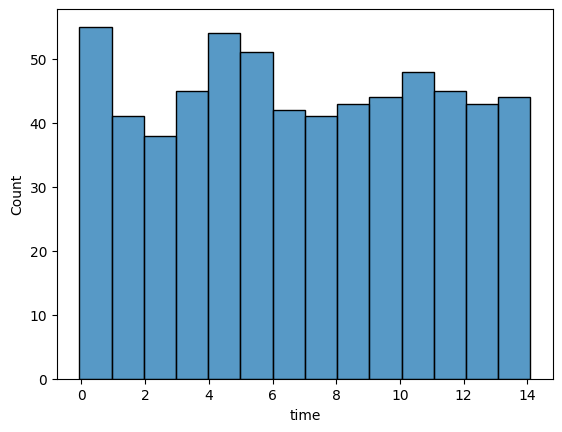

In [ ]:
sns.histplot(df['time'], bins=14)

Sampling was done everyday for almost all processes, as the sampling  distribution looks consistent.

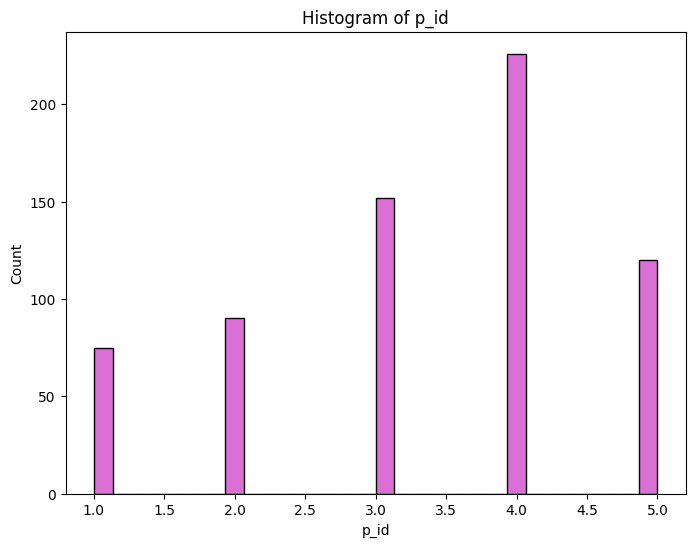

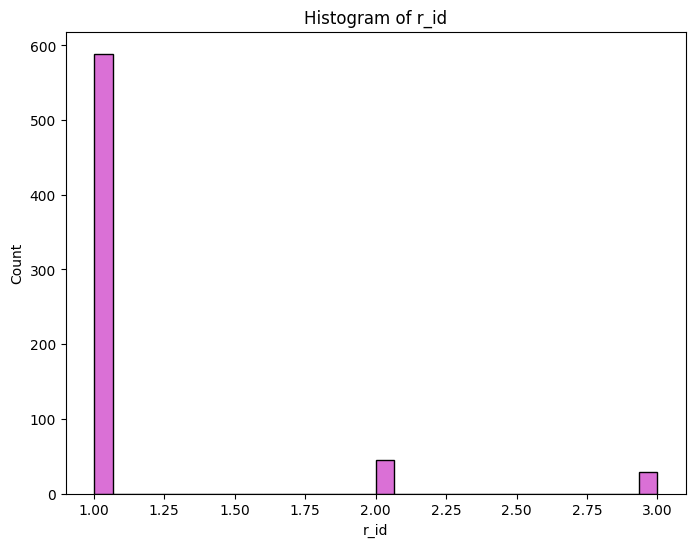

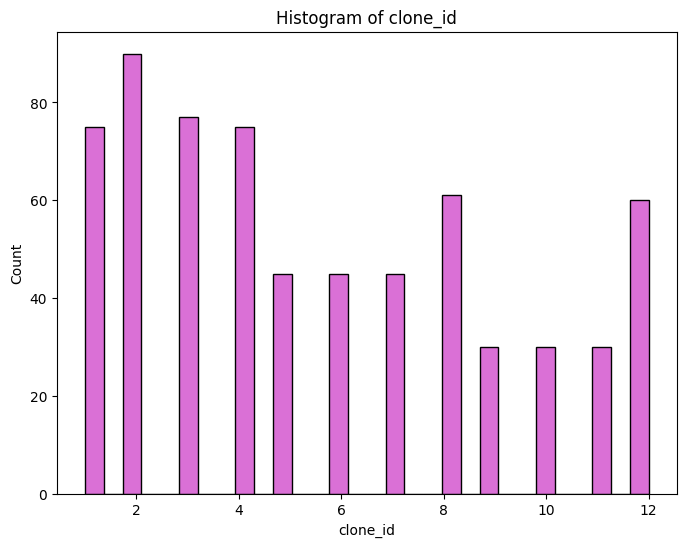

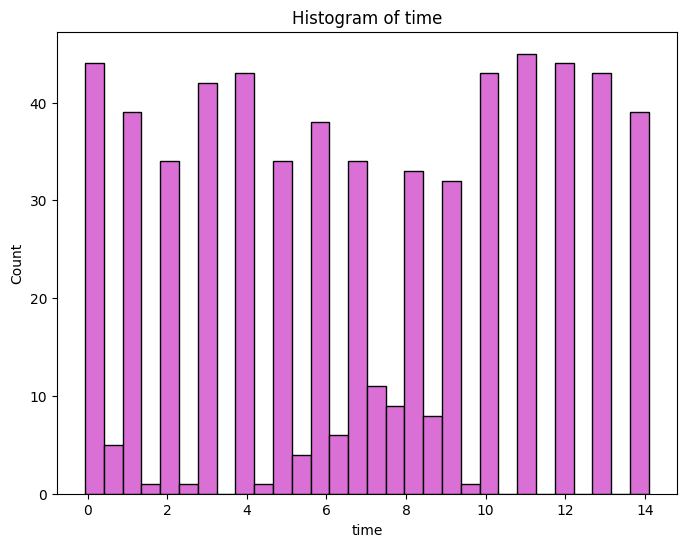

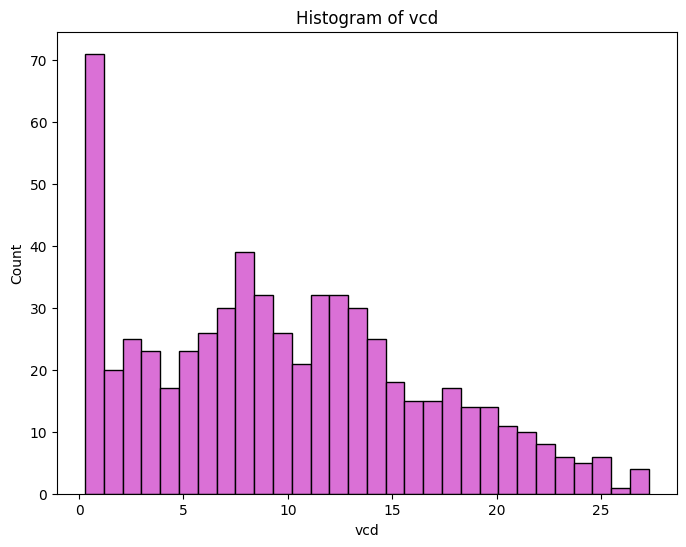

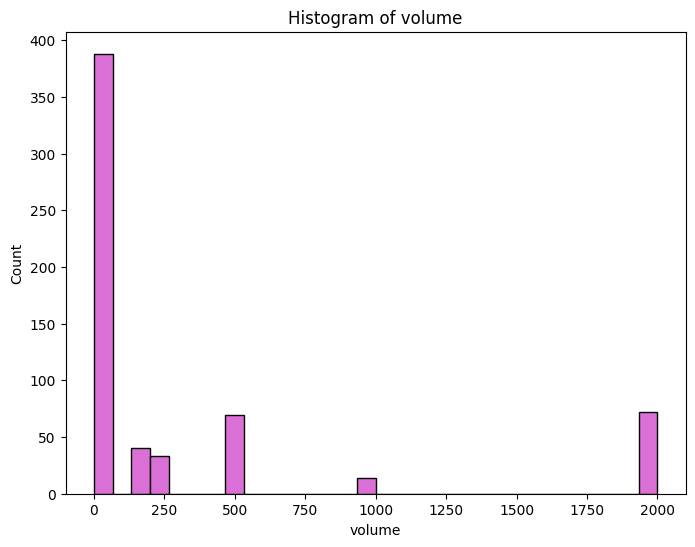

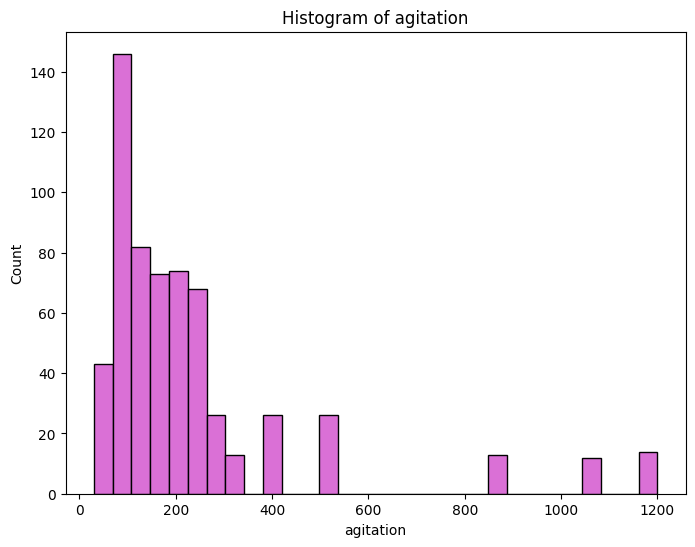

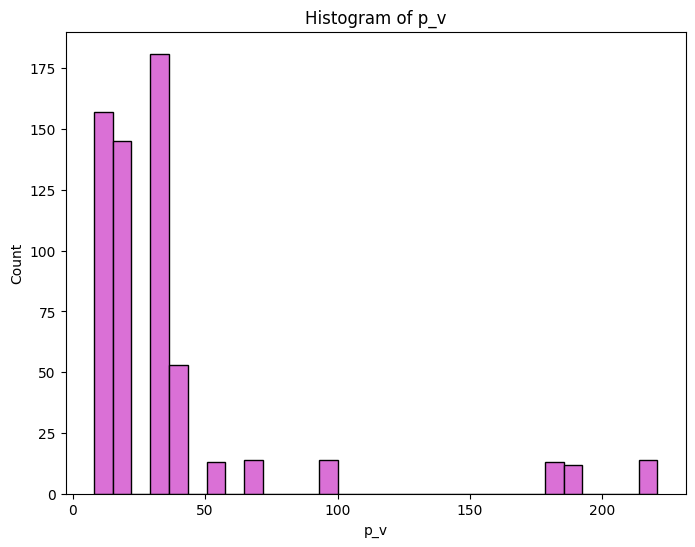

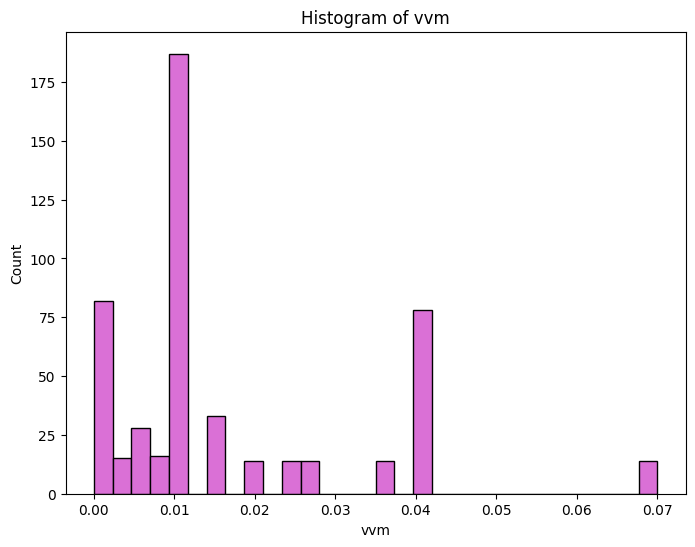

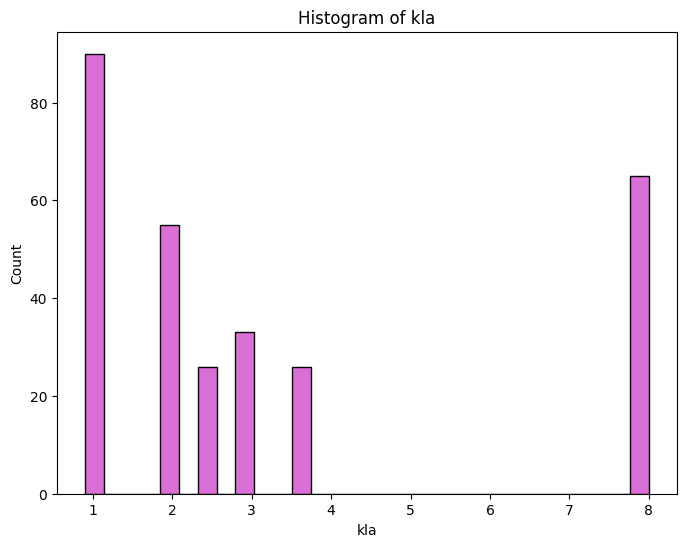

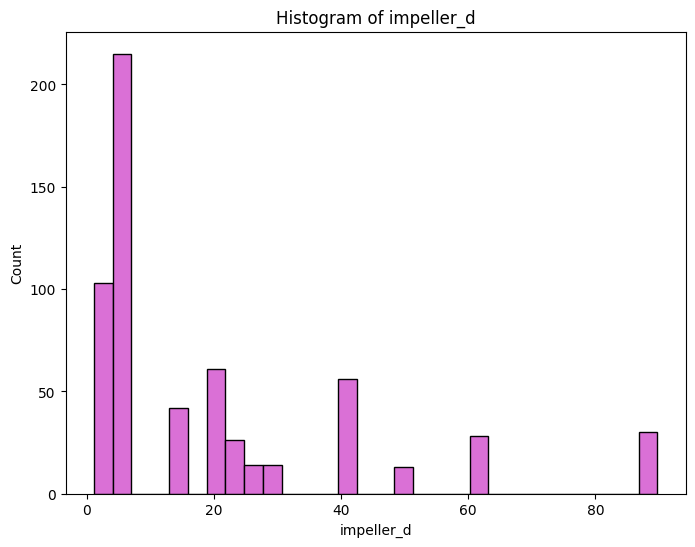

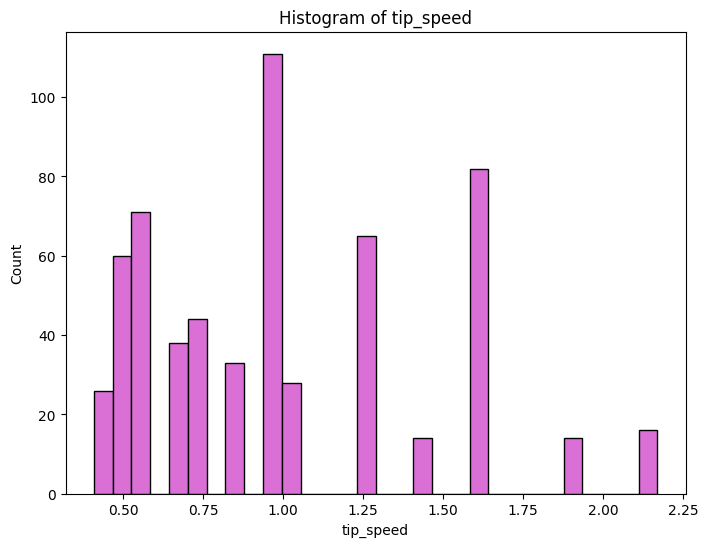

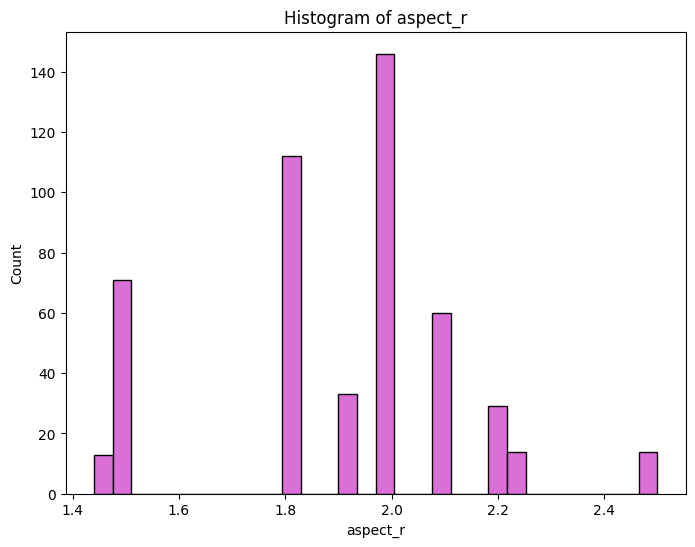

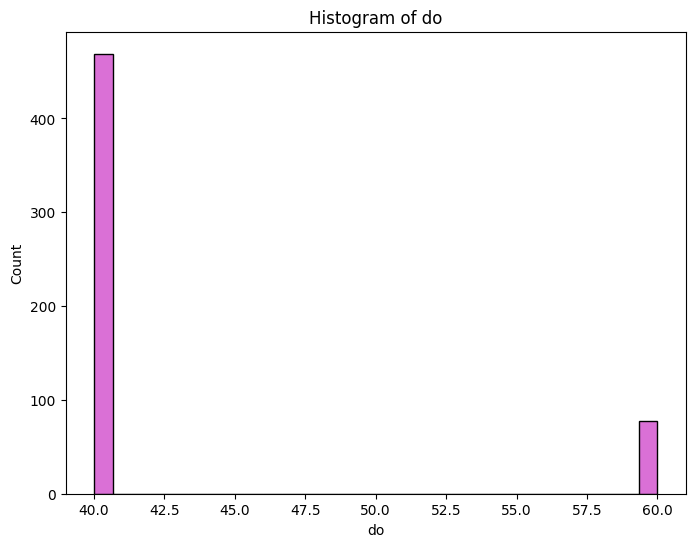

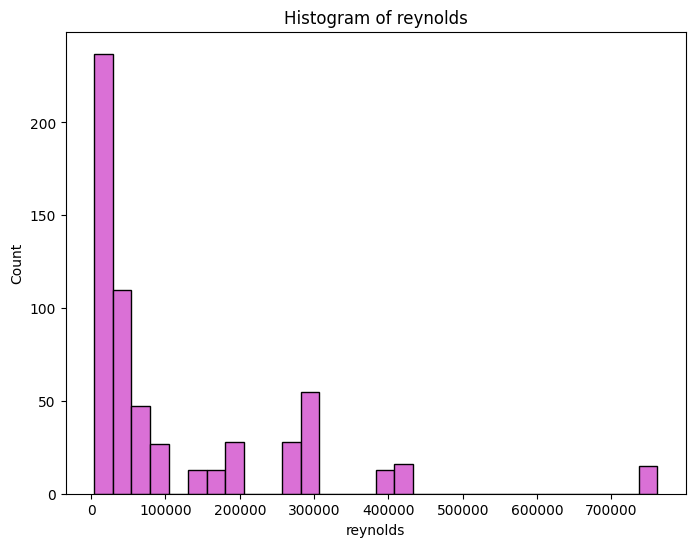

In [ ]:
for column in df.select_dtypes(include='number').columns:
    plt.figure(figsize=(8, 6))
    plt.hist(df[column].dropna(), bins=30, color='orchid', edgecolor='black')
    plt.title(f'Histogram of {column}')
    plt.xlabel(column)
    plt.ylabel('Count')

There are 5 distinct processes and 12 different clones represented in the dataset.
Sampling was performed daily.

VCD values are evenly distributed with a pronounced peak around 0.3–0.5 × 10⁶ cells/mL, consistent with typical seeding densities for most processes. Additional peaks at approximately 8 and 12 × 10⁶ cells/mL align with expected growth profiles for CHO cells in bioprocessing.

The dataset includes more observations from small-scale experiments.

Agitation speed ranges from ~30 to 300 rpm, which matches realistic bioprocess operating conditions. Values exceeding 300 rpm likely correspond to very small-scale systems (e.g., 15 mL), and could be considered outliers, as such high speeds would cause excessive shear stress in larger scales. The same consideration applies to P/V values.

VVM values range from 0.00 to 0.07, indicating low aeration rates without apparent outliers.
kLa values also show no significant outliers.

Impeller diameter distribution mirrors that of volume, confirming that small-scale vessels were used more frequently.
Tip speed distribution closely follows agitation speed, which is consistent with physical expectations.

Aspect ratio ranges between 1.5 and 2.5, which is realistic for bioreactors.

DO values cluster around 40% and 60%, both typical setpoints in bioprocess control.

Reynolds number distributions show that most processes operated in the turbulent regime, which is expected in bioprocessing. Values below 10,000 (laminar flow) can be considered outliers.


<Axes: xlabel='p_id', ylabel='vcd'>

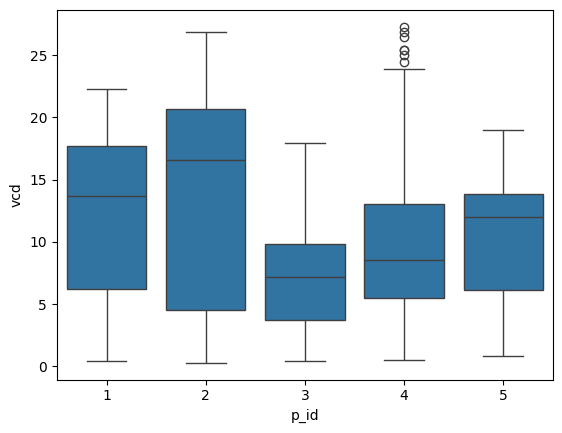

In [ ]:
sns.boxplot(x='p_id', y='vcd', data=df)

Process 1 has a median VCD of approximately 14–15. The distribution shows a wider spread, with values ranging from 0 to 23. This indicates variable growth or differences in sampling across runs.

Process 2 shows the highest median VCD, around 17. It also has an even broader range of values, from 0 up to 27. This suggests strong growth performance overall

Process 3 has a noticeably lower median VCD of about 7. The box is narrower, indicating less variation and consistently lower cell densities.

Process 4 has a median VCD between 10 and 12. It also displays several high outliers exceeding 25, which suggests occasional runs with unusually high cell densities or an unusual clone (reaching higher biomass overall)

Process 5 has a median around 12–13 with a moderate spread in values and more consistent performance.

/tmp/ipython-input-21-170735696.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(data=df_p4, x='time', y='vcd', hue='clone_id', style='vessel', ci=None)


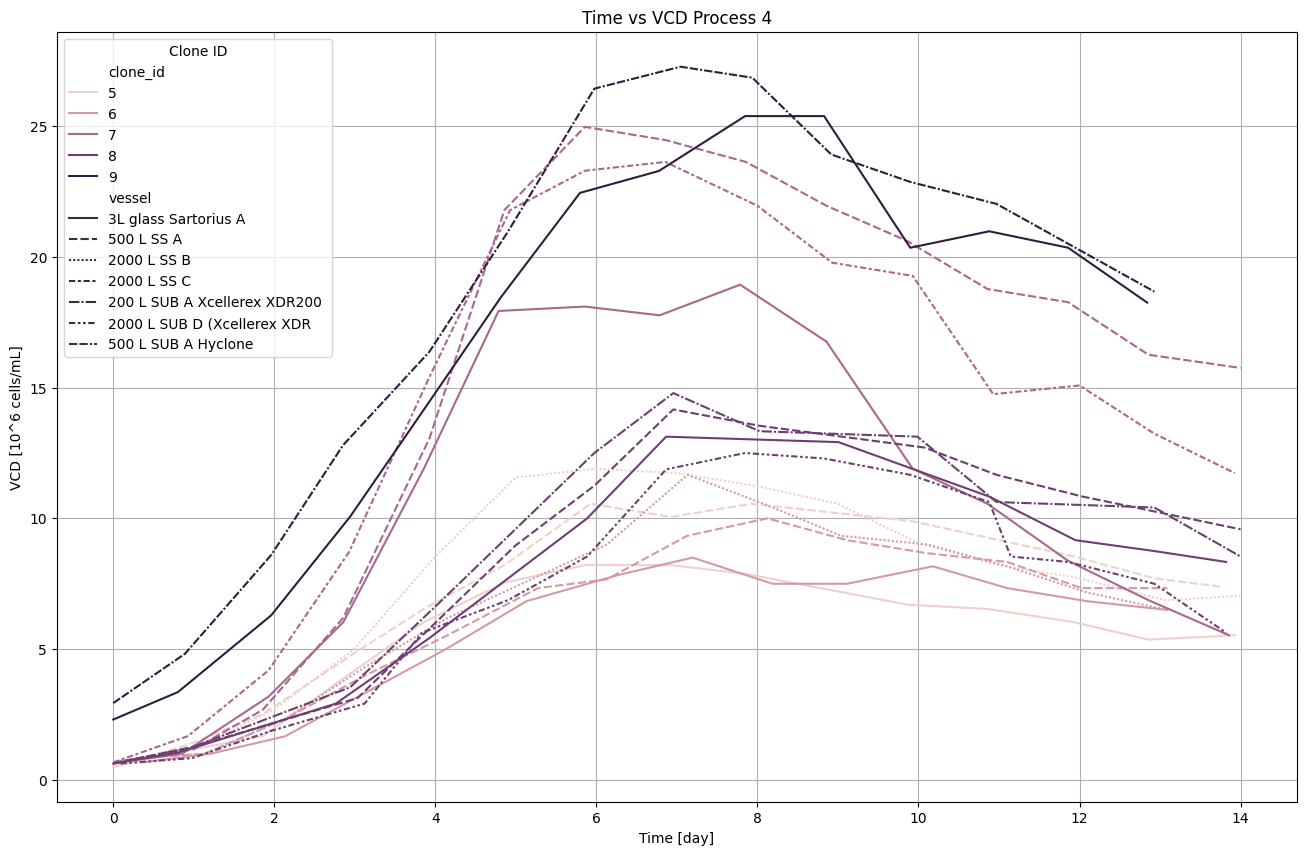

In [ ]:
df_p4 = df[df['p_id'] == 4]
plt.figure(figsize=(16, 10))
sns.lineplot(data=df_p4, x='time', y='vcd', hue='clone_id', style='vessel', ci=None)

plt.title('Time vs VCD Process 4')
plt.xlabel('Time [day]')
plt.ylabel('VCD [10^6 cells/mL]')
plt.legend(title='Clone ID')
plt.grid(True)

**Process 4:**

There is a clear distinction between the clones. Clone 9 and Clone 7 show the highest growth, reaching the greatest cell densities. Overall, all processes appear consistent and reliable.

In [ ]:
df_p1 = df[df['p_id'] == 1]

/tmp/ipython-input-23-1962136475.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(data=df_p1, x='time', y='vcd', hue='clone_id', style='vessel', ci=None)


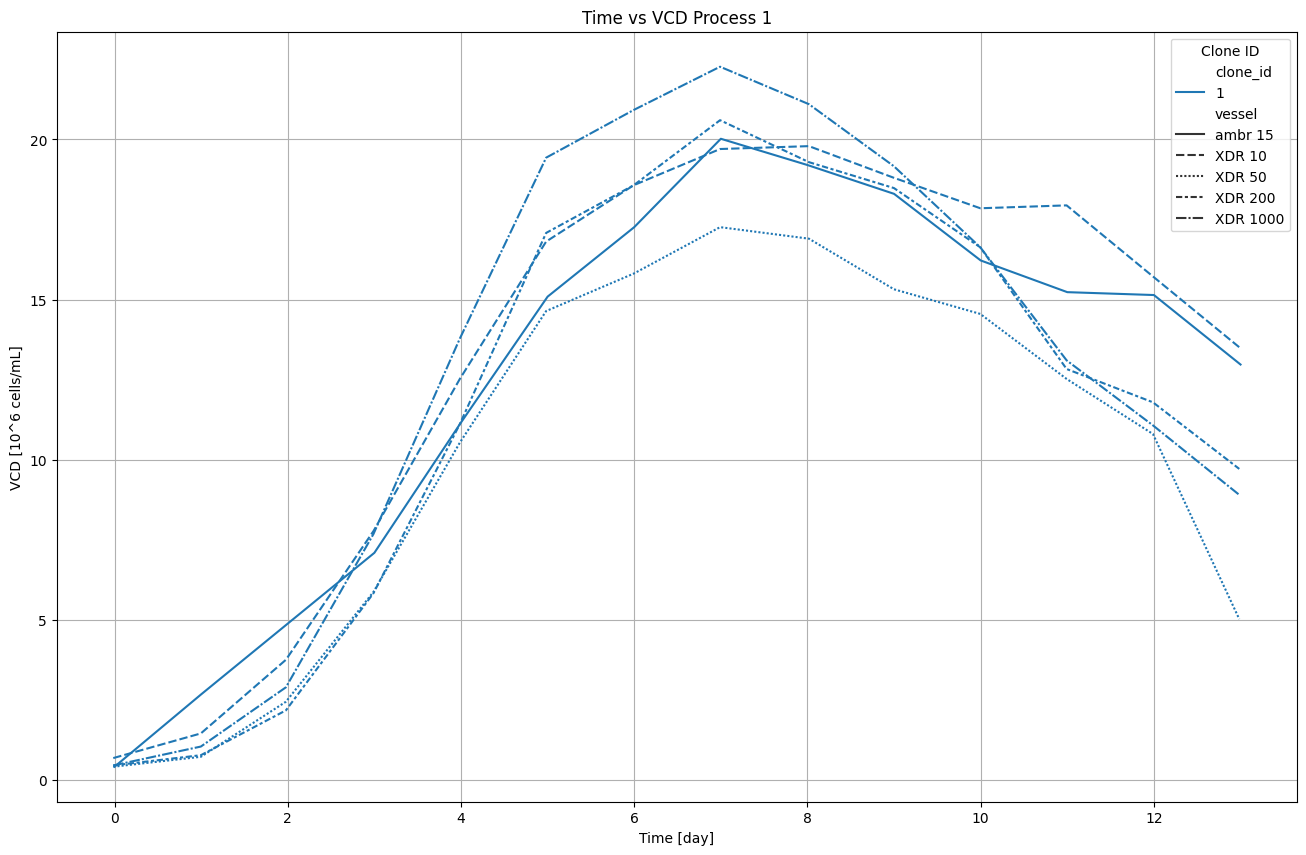

In [ ]:
plt.figure(figsize=(16, 10))
sns.lineplot(data=df_p1, x='time', y='vcd', hue='clone_id', style='vessel', ci=None)

plt.title('Time vs VCD Process 1')
plt.xlabel('Time [day]')
plt.ylabel('VCD [10^6 cells/mL]')
plt.legend(title='Clone ID')
plt.grid(True)

**Process 1**

There was only one clone used for scale up. overall, all processes appear consistent and reliable.

/tmp/ipython-input-24-148432561.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(data=df_p2, x='time', y='vcd', hue='clone_id', style='vessel', ci=None)


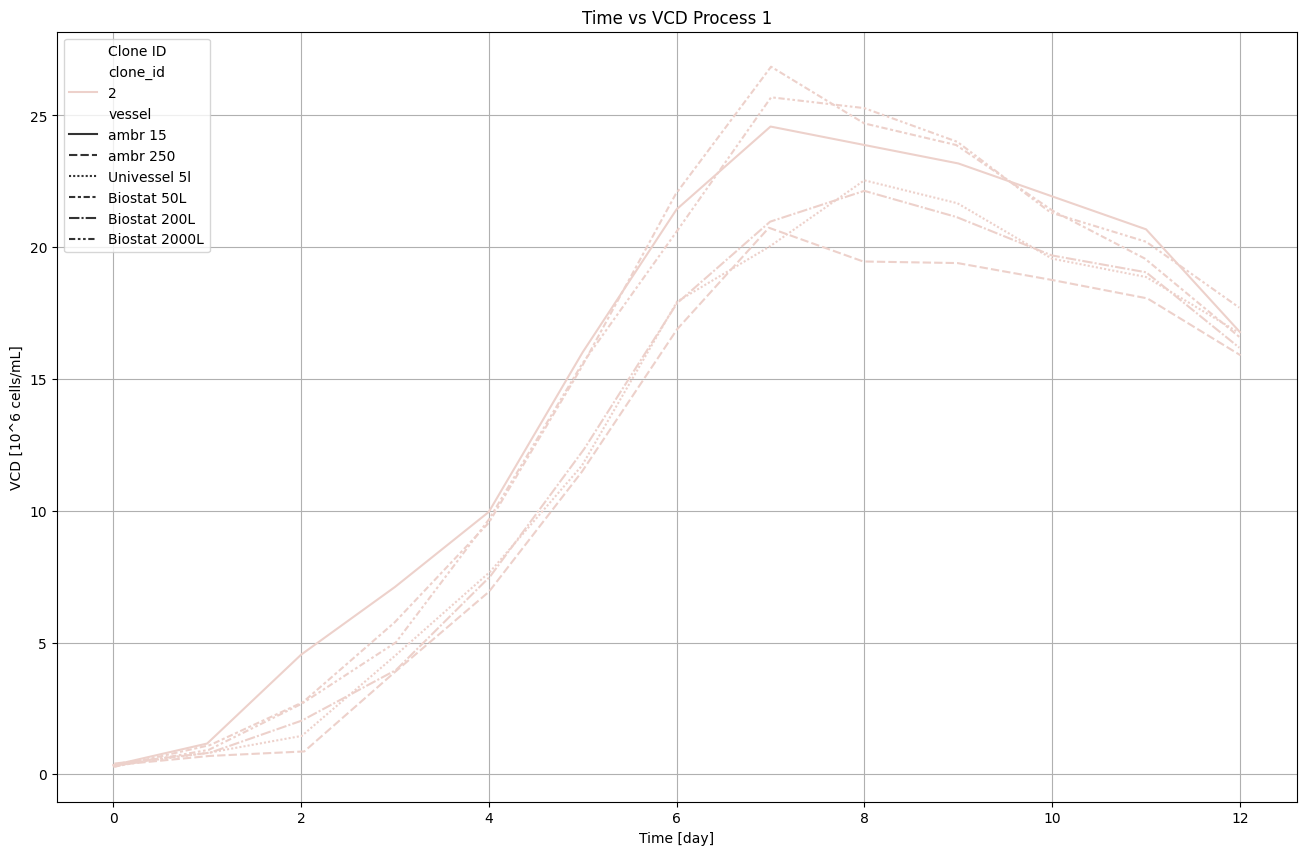

In [ ]:
df_p2 = df[df['p_id'] == 2]
plt.figure(figsize=(16, 10))
sns.lineplot(data=df_p2, x='time', y='vcd', hue='clone_id', style='vessel', ci=None)

plt.title('Time vs VCD Process 1')
plt.xlabel('Time [day]')
plt.ylabel('VCD [10^6 cells/mL]')
plt.legend(title='Clone ID')
plt.grid(True)

**Process 2**

There was only one clone used for scale up. overall, all processes appear consistent and reliable.

/tmp/ipython-input-25-737616735.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(data=df_p3, x='time', y='vcd', hue='clone_id', style='vessel', ci=None)


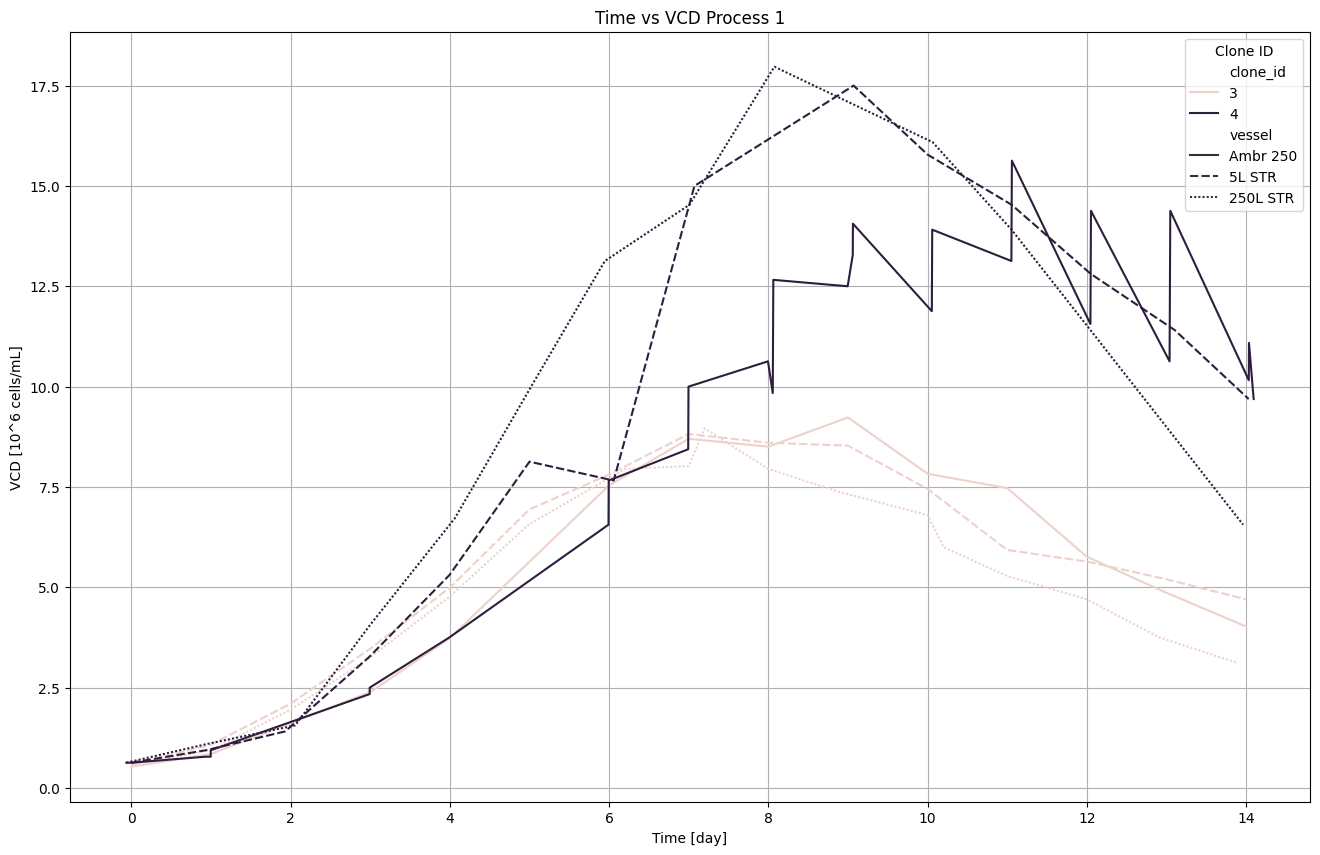

In [ ]:
df_p3 = df[df['p_id'] == 3]
plt.figure(figsize=(16, 10))
sns.lineplot(data=df_p3, x='time', y='vcd', hue='clone_id', style='vessel', ci=None)

plt.title('Time vs VCD Process 1')
plt.xlabel('Time [day]')
plt.ylabel('VCD [10^6 cells/mL]')
plt.legend(title='Clone ID')
plt.grid(True)

**Process 3**

Two clones were used for scale-up. Overall, the processes appear consistent and reliable. However, there is evidence of sampling issues in the Ambr 250 system for Clone 4, indicated by repeated sampling points and marked variability.

/tmp/ipython-input-26-897330297.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(data=df_p5, x='time', y='vcd', hue='clone_id', style='vessel', ci=None)


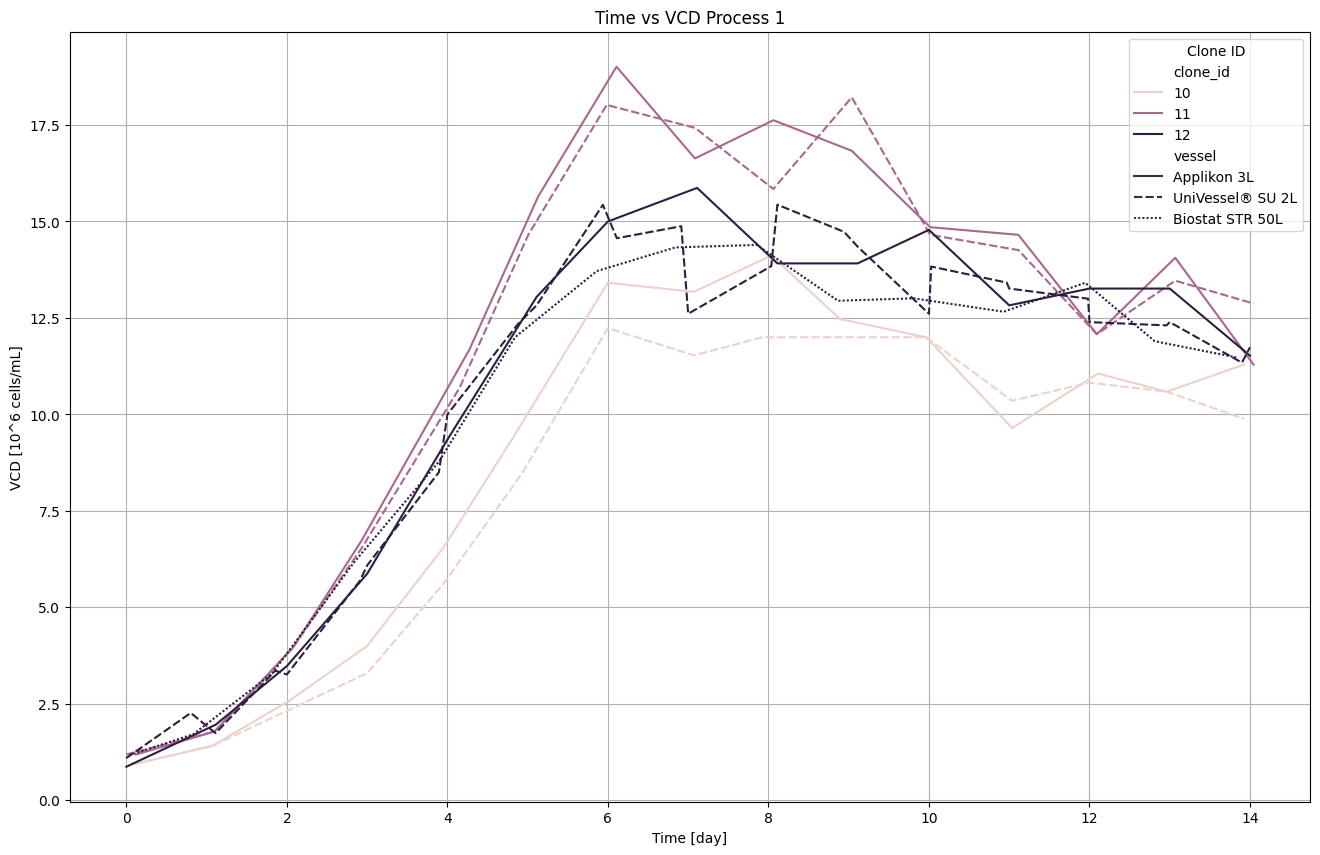

In [ ]:
df_p5 = df[df['p_id'] == 5]
plt.figure(figsize=(16, 10))
sns.lineplot(data=df_p5, x='time', y='vcd', hue='clone_id', style='vessel', ci=None)

plt.title('Time vs VCD Process 1')
plt.xlabel('Time [day]')
plt.ylabel('VCD [10^6 cells/mL]')
plt.legend(title='Clone ID')
plt.grid(True)

**Process 5**

Three clones were used for scale-up. Overall, the processes appear consistent and reliable. However, there is evidence of sampling inconsistencies or variability in VCD measurement methods across all systems, indicated by pronounced fluctuations and the absence of a smooth growth curve.

<Axes: >

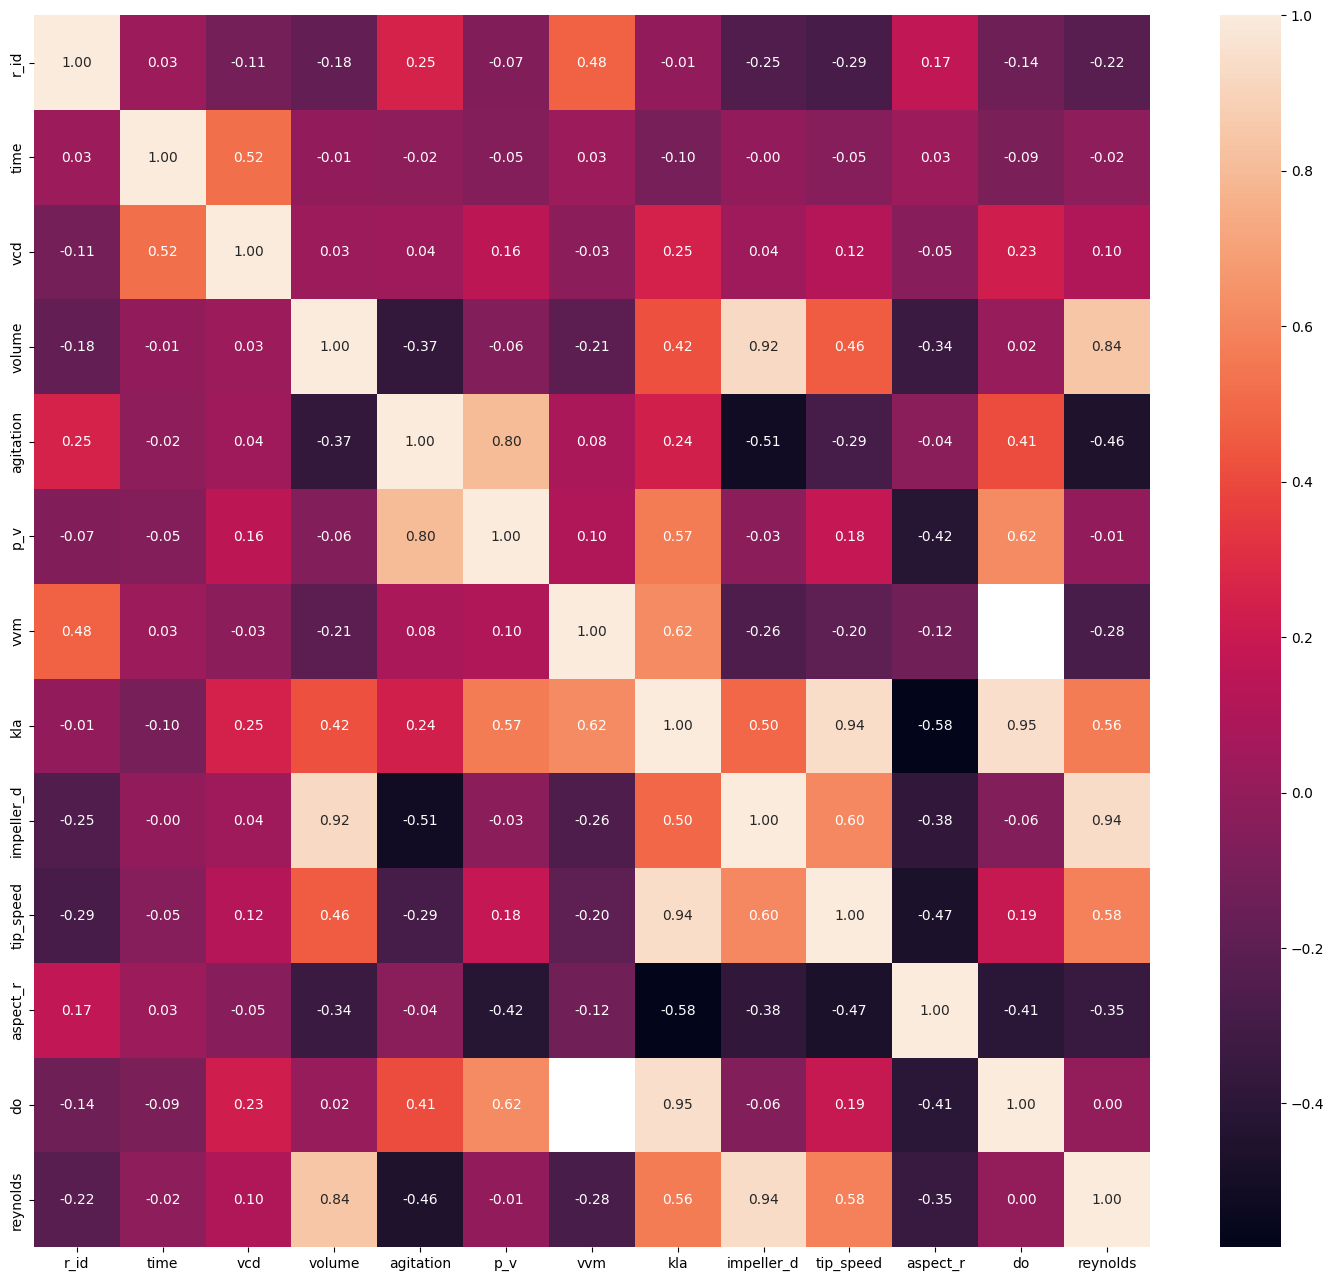

In [ ]:
numeric_df = df.select_dtypes(include=['number']).drop(columns=['p_id', 'clone_id'])
corr = numeric_df.corr()
plt.figure(figsize=(18, 16))
sns.heatmap(corr, annot=True, fmt='.2f')

The strongest correlation is between impeller diameter and bioreactor volume, which is expected because larger vessels need proportionally larger impellers for proper mixing.

Volume also correlates with Reynolds number, reflecting scale-dependent flow conditions.

kLa correlates with DO, since better oxygen transfer supports higher DO setpoints (but DO is just a setpoint)

High correlations appear between impeller diameter and tip speed, Reynolds and tip speed, and Reynolds and kLa, all consistent with how larger, faster-moving impellers increase turbulence and oxygen transfer.


Reynolds and agitation show a negative correlation because larger vessels (which have higher Reynolds numbers overall) often run at lower rpm. This is a common scale-up strategy to reduce shear stress while still maintaining turbulent flow through increased impeller size and liquid volume.


Tip speed correlates with volume because scale-up preserves shear conditions by increasing impeller size.

Impeller diameter also correlates with kLa, as larger impellers enhance mixing and transfer.

Aspect ratio shows negative correlations with P/V, kLa, tip speed, DO, and volume.

VVM correlates with kLa (more sparging improves oxygen transfer), P/V with kLa (more power increases transfer).

Time correlates with VCD (cell density rises and drop over culture duration).


Text(0.5, 1.0, 'Aspect ratio vs Volume')

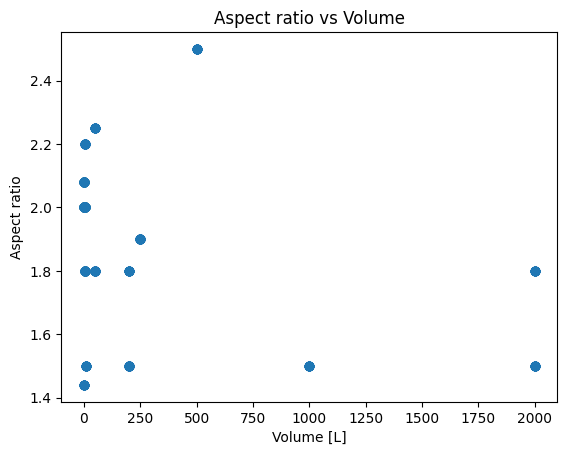

In [ ]:
plt.scatter(df['volume'], df['aspect_r'])
plt.xlabel('Volume [L]')
plt.ylabel('Aspect ratio')
plt.title('Aspect ratio vs Volume')

**Data Imputation**

I will split the dataset by groups by p_id and clone_id to preserve temporal structure, avoids leakage into test/validation dataset and to allow to test generalization to new processes or clones.

~70–80% of (p_id, clone_id) pairs for train.

~10–15% for validation.

~10–15% for test

In [ ]:
pairs = df[['p_id', 'clone_id']].drop_duplicates()
print(pairs)

     p_id  clone_id
0       1         1
75      2         2
165     3         3
242     3         4
317     4         5
362     4         6
407     4         7
452     4         8
513     4         9
543     5        10
573     5        11
603     5        12


In [ ]:
print(pairs.groupby('p_id')['clone_id'].nunique())


p_id
1    1
2    1
3    2
4    5
5    3
Name: clone_id, dtype: int64


Make a list of unique (p_id, clone_id) pairs -> Shuffle that list to randomize assignment -> Divide the list into train/val/test pairs->
Select all rows in the original dataframe that belong to those pairs.

In [ ]:
pairs = pairs.sample(frac=1, random_state=42).reset_index(drop=True)
print(pairs)

    p_id  clone_id
0      5        11
1      5        10
2      1         1
3      4         9
4      4         6
5      3         3
6      2         2
7      5        12
8      4         5
9      4         8
10     3         4
11     4         7


Shuffle all unique (process, clone) pairs randomly (but reproducibly with random_state=42), reset their index so it’s clean.

In [ ]:
n = len(pairs)
train_end = int(0.7 * n)
val_end = int(0.85 * n)

In [ ]:
train_pairs = pairs.iloc[:train_end]
val_pairs = pairs.iloc[train_end:val_end]
test_pairs = pairs.iloc[val_end:]

In [ ]:
len(train_pairs)

8

In [ ]:
len(val_pairs)

2

In [ ]:
len(test_pairs)

2

In [ ]:
print(len(train_pairs) + len(val_pairs) + len(test_pairs))

12


In [ ]:
def filter_pairs(df, pairs):
    return df.merge(pairs, on=['p_id', 'clone_id'])

In [ ]:
train_df = filter_pairs(df, train_pairs)
val_df = filter_pairs(df, val_pairs)
test_df = filter_pairs(df, test_pairs)

In [ ]:
train_df.head()

,vessel,p_id,r_id,clone_id,time,vcd,volume,agitation,p_v,vvm,kla,impeller_d,tip_speed,aspect_r,do,reynolds
0,ambr 15,1,1,1,0.0,0.41,15.0,1200.0,220.8,0.0,NaN,NaN,NaN,NaN,NaN,NaN
1,ambr 15,1,1,1,1.0,2.67,15.0,1200.0,220.8,0.0,NaN,NaN,NaN,NaN,NaN,NaN
2,ambr 15,1,1,1,2.0,4.88,15.0,1200.0,220.8,0.0,NaN,NaN,NaN,NaN,NaN,NaN
3,ambr 15,1,1,1,3.0,7.09,15.0,1200.0,220.8,0.0,NaN,NaN,NaN,NaN,NaN,NaN
4,ambr 15,1,1,1,4.0,11.16,15.0,1200.0,220.8,0.0,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
train_df.tail()

,vessel,p_id,r_id,clone_id,time,vcd,volume,agitation,p_v,vvm,kla,impeller_d,tip_speed,aspect_r,do,reynolds
432,Biostat STR 50L,5,1,12,9.8088,13.008509,50.0,100.0,9.6,NaN,NaN,14.3,0.75,1.8,40.0,48348.0
433,Biostat STR 50L,5,1,12,10.9313,12.659857,50.0,100.0,9.6,NaN,NaN,14.3,0.75,1.8,40.0,48348.0
434,Biostat STR 50L,5,1,12,11.9473,13.410928,50.0,100.0,9.6,NaN,NaN,14.3,0.75,1.8,40.0,48348.0
435,Biostat STR 50L,5,1,12,12.8138,11.895509,50.0,100.0,9.6,NaN,NaN,14.3,0.75,1.8,40.0,48348.0
436,Biostat STR 50L,5,1,12,13.8275,11.478653,50.0,100.0,9.6,NaN,NaN,14.3,0.75,1.8,40.0,48348.0


In [ ]:
val_df.head()

,vessel,p_id,r_id,clone_id,time,vcd,volume,agitation,p_v,vvm,kla,impeller_d,tip_speed,aspect_r,do,reynolds
0,3L glass Sartorius A,4,1,5,0.000000,0.502793,3.0,260.0,13.38,0.0,NaN,6.98,0.95,2.0,40.0,29957.82
1,3L glass Sartorius A,4,1,5,1.000000,1.173184,3.0,260.0,13.38,0.0,NaN,6.98,0.95,2.0,40.0,29957.82
2,3L glass Sartorius A,4,1,5,1.857143,1.675978,3.0,260.0,13.38,0.0,NaN,6.98,0.95,2.0,40.0,29957.82
3,3L glass Sartorius A,4,1,5,3.000000,4.189944,3.0,260.0,13.38,0.0,NaN,6.98,0.95,2.0,40.0,29957.82
4,3L glass Sartorius A,4,1,5,3.857143,6.033520,3.0,260.0,13.38,0.0,NaN,6.98,0.95,2.0,40.0,29957.82


In [ ]:
test_df.head()

,vessel,p_id,r_id,clone_id,time,vcd,volume,agitation,p_v,vvm,kla,impeller_d,tip_speed,aspect_r,do,reynolds
0,Ambr 250,3,1,4,0.0016,0.63,0.25,300.0,8.0,0.04,2.0,2.6,0.408,2.0,40.0,4794.77
1,Ambr 250,3,1,4,0.9984,0.94,0.25,300.0,8.0,0.04,2.0,2.6,0.408,2.0,40.0,4794.77
2,Ambr 250,3,1,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Ambr 250,3,1,4,2.9942,2.34,0.25,300.0,8.0,0.04,2.0,2.6,0.408,2.0,40.0,4794.77
4,Ambr 250,3,1,4,3.9938,3.75,0.25,300.0,8.0,0.04,2.0,2.6,0.408,2.0,40.0,4794.77


In [ ]:
print(len(train_df), len(val_df), len(test_df))

437 106 120


**Data Imputation**

1. aspect ratio


In [ ]:
df['aspect_r'].isna().sum()

np.int64(171)

In [ ]:
nan_asp_r_train = train_df[train_df['aspect_r'].isna()].groupby('p_id').size()
print(nan_asp_r_train)

p_id
1    19
2    25
3     5
4    34
dtype: int64


In [ ]:
df_p4 = train_df[train_df['p_id'] == 4]
total_p4 = len(df_p4)
print("Total rows in Process 4:", total_p4)
missing_p4 = df_p4['aspect_r'].isna().sum()
print("Missing aspect_ratio in Process 4:", missing_p4)

Total rows in Process 4: 75
Missing aspect_ratio in Process 4: 34


In [ ]:
df_p4.describe()

,p_id,r_id,clone_id,time,vcd,volume,agitation,p_v,vvm,kla,impeller_d,tip_speed,aspect_r,do,reynolds
count,75.0,75.0,75.000000,68.000000,68.000000,68.000000,68.000000,68.000000,68.000000,0.0,68.000000,68.000000,41.000000,68.0,68.000000
mean,4.0,1.0,7.200000,6.617612,10.824129,589.426471,150.558824,25.609118,0.008088,NaN,27.993088,1.236029,2.170732,40.0,162763.886471
std,0.0,0.0,1.479591,4.068931,7.812893,726.630340,94.413726,10.200013,0.007582,NaN,20.646381,0.340518,0.240046,0.0,115098.309915
min,4.0,1.0,6.000000,0.000000,0.666667,3.000000,30.000000,13.380000,0.000000,NaN,6.980000,0.950000,2.000000,40.0,29957.820000
25%,4.0,1.0,6.000000,3.086175,6.000000,3.000000,77.000000,13.380000,0.000000,NaN,6.980000,0.950000,2.000000,40.0,29957.820000
50%,4.0,1.0,6.000000,6.910850,8.250000,500.000000,125.000000,31.740000,0.010000,NaN,25.060000,0.960000,2.000000,40.0,185558.300000
75%,4.0,1.0,9.000000,10.109700,18.304196,500.000000,260.000000,31.860000,0.010000,NaN,40.700000,1.640000,2.500000,40.0,264925.600000
max,4.0,1.0,9.000000,13.091100,27.272727,2000.000000,260.000000,37.250000,0.020000,NaN,61.110000,1.640000,2.500000,40.0,301231.010000


Aspect ratio:

mean = 2.17

median = 2

range between 2 and 2.5

Aspect ratio values have a narrow, realistic engineering range (1.5–2.5).

Since aspect ratio values ranged between 2.0 and 2.5 (mean ≈ 2.17, median = 2), imputing with the median provides a realistic, representative value consistent with the bioreactor geometries in the dataset. This approach minimizes the impact of missing data while avoiding bias from extreme values.

Aspect ratio is generally held constant within a scale-up process to ensure geometric similarity across scales. For this reason, I imputed missing aspect ratio values using the median aspect ratio observed within the same process. This approach maintains consistency with typical bioprocess design practices, where aspect ratio does not usually vary between vessels used in the same process.

In [ ]:
train_df.loc[(train_df['p_id'] == 4) & (train_df['aspect_r'].isna()), 'aspect_r'] = 2

In [ ]:
df_p4 = train_df[train_df['p_id'] == 4]
total_p4 = len(df_p4)
print("Total rows in Process 4 (train):", total_p4)
missing_p4 = df_p4['aspect_r'].isna().sum()
print("Missing aspect_ratio in Process 4 (train):", missing_p4)

Total rows in Process 4 (train): 75
Missing aspect_ratio in Process 4 (train): 0


In [ ]:
nan_asp_r_train = train_df[train_df['aspect_r'].isna()].groupby('p_id').size()
print(nan_asp_r_train)

p_id
1    19
2    25
3     5
dtype: int64


In [ ]:
df_p1 = train_df[train_df['p_id'] == 1]
total_p1 = len(df_p1)
print("Total rows in Process 1 (train):", total_p1)
missing_p1 = df_p1['aspect_r'].isna().sum()
print("Missing aspect_ratio in Process 1 (train):", missing_p1)

Total rows in Process 1 (train): 75
Missing aspect_ratio in Process 1 (train): 19


In [ ]:
df_p1.describe()

,p_id,r_id,clone_id,time,vcd,volume,agitation,p_v,vvm,kla,impeller_d,tip_speed,aspect_r,do,reynolds
count,75.0,75.0,75.0,75.000000,70.000000,70.000000,70.000000,70.000000,70.000000,0.0,56.000000,56.000000,56.000000,0.0,56.000000
mean,1.0,1.0,1.0,6.993747,12.100286,255.000000,339.000000,90.560000,0.031200,NaN,21.180000,1.352500,1.687500,NaN,97506.000000
std,0.0,0.0,0.0,4.351782,6.737511,381.602267,433.893395,70.189702,0.022819,NaN,6.084195,0.372828,0.327699,NaN,54980.418355
min,1.0,1.0,1.0,-0.014656,0.410000,10.000000,97.000000,33.000000,0.000000,NaN,13.600000,1.030000,1.500000,NaN,44390.000000
25%,1.0,1.0,1.0,2.994927,6.175000,15.000000,121.000000,33.000000,0.023500,NaN,18.640000,1.030000,1.500000,NaN,61162.250000
50%,1.0,1.0,1.0,6.990981,13.645000,50.000000,133.000000,66.000000,0.027500,NaN,20.320000,1.225000,1.500000,NaN,79140.000000
75%,1.0,1.0,1.0,10.992108,17.702500,200.000000,144.000000,100.000000,0.035000,NaN,22.860000,1.547500,1.687500,NaN,115483.750000
max,1.0,1.0,1.0,14.000000,22.270000,1000.000000,1200.000000,220.800000,0.070000,NaN,30.480000,1.930000,2.250000,NaN,187354.000000


Aspect ratio

mean = 1.69

median= 1.5

In [ ]:
train_df.loc[(train_df['p_id'] == 1) & (train_df['aspect_r'].isna()), 'aspect_r'] = 1.5

In [ ]:
nan_asp_r_train = train_df[train_df['aspect_r'].isna()].groupby('p_id').size()
print(nan_asp_r_train)

p_id
2    25
3     5
dtype: int64


In [ ]:
df_p2 = train_df[train_df['p_id'] == 2]
total_p2 = len(df_p2)
print("Total rows in Process 2 (train):", total_p2)
missing_p2 = df_p2['aspect_r'].isna().sum()
print("Missing aspect_ratio in Process 2 (train):", missing_p2)

Total rows in Process 2 (train): 90
Missing aspect_ratio in Process 2 (train): 25


In [ ]:
df_p2.describe()

,p_id,r_id,clone_id,time,vcd,volume,agitation,p_v,vvm,kla,impeller_d,tip_speed,aspect_r,do,reynolds
count,90.0,90.0,90.0,90.000000,77.000000,77.000000,77.000000,77.000000,0.0,65.0,77.000000,77.000000,65.000000,77.0,77.000000
mean,2.0,1.0,2.0,7.001334,13.376883,380.758831,422.792208,84.919481,NaN,8.0,16.311688,1.161091,1.728000,60.0,116627.415584
std,0.0,0.0,0.0,4.339489,8.681402,737.969963,379.657163,71.343447,NaN,0.0,16.606855,0.216726,0.145121,0.0,140573.439023
min,2.0,1.0,2.0,-0.000125,0.290000,0.015000,70.000000,29.600000,NaN,8.0,1.100000,0.660000,1.440000,60.0,3638.000000
25%,2.0,1.0,2.0,3.010838,4.490000,0.250000,121.000000,30.400000,NaN,8.0,2.600000,1.252000,1.800000,60.0,13910.000000
50%,2.0,1.0,2.0,6.997846,16.600000,50.000000,162.000000,30.500000,NaN,8.0,14.300000,1.252000,1.800000,60.0,79728.000000
75%,2.0,1.0,2.0,10.996758,20.680000,200.000000,855.000000,183.000000,NaN,8.0,22.500000,1.254000,1.800000,60.0,147427.000000
max,2.0,1.0,2.0,14.000000,26.850000,2000.000000,1050.000000,190.000000,NaN,8.0,49.200000,1.258000,1.800000,60.0,407807.000000


Aspect ratio

mean = 1.73

median= 1.80

In [ ]:
train_df.loc[(train_df['p_id'] == 2) & (train_df['aspect_r'].isna()), 'aspect_r'] = 1.8

In [ ]:
nan_asp_r_train = train_df[train_df['aspect_r'].isna()].groupby('p_id').size()
print(nan_asp_r_train)

p_id
3    5
dtype: int64


In [ ]:
df_p3 = train_df[train_df['p_id'] == 3]
total_p3 = len(df_p3)
print("Total rows in Process 3 (train):", total_p3)
missing_p3 = df_p3['aspect_r'].isna().sum()
print("Missing aspect_ratio in Process 3 (train):", missing_p3)

Total rows in Process 3 (train): 77
Missing aspect_ratio in Process 3 (train): 5


In [ ]:
df_p3.describe()

,p_id,r_id,clone_id,time,vcd,volume,agitation,p_v,vvm,kla,impeller_d,tip_speed,aspect_r,do,reynolds
count,77.0,77.000000,77.0,72.000000,72.000000,72.000000,72.000000,72.000000,72.000000,72.000000,72.000000,72.000000,72.000000,72.0,72.000000
mean,3.0,1.558442,3.0,7.312500,5.428611,63.677083,278.333333,17.415278,0.027500,2.629167,7.866667,0.657056,2.016667,40.0,27204.222778
std,0.0,0.786289,0.0,4.305514,2.761087,108.344386,151.861687,10.438953,0.013789,0.640738,7.260699,0.152714,0.103461,0.0,28938.924960
min,3.0,1.000000,3.0,0.000000,0.430000,0.250000,80.000000,8.000000,0.010000,2.000000,2.600000,0.408000,1.900000,40.0,4794.770000
25%,3.0,1.000000,3.0,4.000000,3.575000,0.250000,170.000000,8.000000,0.015000,2.000000,2.600000,0.544000,1.975000,40.0,6393.030000
50%,3.0,1.000000,3.0,7.600000,5.675000,0.250000,300.000000,18.700000,0.040000,2.400000,2.600000,0.681000,2.000000,40.0,7991.280000
75%,3.0,2.000000,3.0,11.000000,7.950000,66.250000,400.000000,18.900000,0.040000,3.000000,10.250000,0.759250,2.000000,40.0,36291.750000
max,3.0,3.000000,3.0,14.000000,9.900000,250.000000,500.000000,36.900000,0.040000,3.700000,20.000000,0.838000,2.200000,40.0,75657.000000


Aspect ratio

mean = 2-02

median= 2.0

In [ ]:
train_df.loc[(train_df['p_id'] == 3) & (train_df['aspect_r'].isna()), 'aspect_r'] = 2

In [ ]:
nan_asp_r_train = train_df[train_df['aspect_r'].isna()].groupby('p_id').size()
print(nan_asp_r_train)

Series([], dtype: int64)


In [ ]:
train_df.describe()

,p_id,r_id,clone_id,time,vcd,volume,agitation,p_v,vvm,kla,impeller_d,tip_speed,aspect_r,do,reynolds
count,437.000000,437.000000,437.000000,425.000000,407.000000,407.000000,407.000000,407.000000,300.000000,227.000000,393.000000,393.000000,437.000000,337.000000,393.000000
mean,3.171625,1.132723,5.437071,6.991092,10.403135,228.072924,262.992629,43.312826,0.018713,3.501322,14.556005,0.925069,1.888604,44.569733,75364.237455
std,1.462159,0.423783,4.155664,4.276157,6.865150,511.313001,274.426374,54.375120,0.016787,2.963980,14.447148,0.403316,0.239088,8.409641,99385.618471
min,1.000000,1.000000,1.000000,-0.014656,0.290000,0.015000,30.000000,8.000000,0.000000,0.900000,1.100000,0.408000,1.440000,40.000000,3638.000000
25%,2.000000,1.000000,2.000000,3.000000,4.700000,2.000000,121.000000,16.300000,0.010000,1.000000,5.400000,0.570000,1.800000,40.000000,13825.000000
50%,3.000000,1.000000,3.000000,7.000000,9.647059,5.000000,162.000000,18.900000,0.010000,2.000000,7.000000,0.838000,1.900000,40.000000,29957.820000
75%,5.000000,1.000000,10.000000,10.987308,15.405412,200.000000,260.000000,36.900000,0.027500,8.000000,20.320000,1.252000,2.000000,40.000000,79728.000000
max,5.000000,3.000000,12.000000,14.045802,27.272727,2000.000000,1200.000000,220.800000,0.070000,8.000000,61.110000,1.930000,2.500000,60.000000,407807.000000



Aspect ratio

mean = 1.88

median= 1.90

In [ ]:
print("Total rows in training set:", len(train_df))
missing = train_df['aspect_r'].isna().sum()
print("Missing aspect_ratio in training set:", missing)

Total rows in training set: 437
Missing aspect_ratio in training set: 0


As the median for the training set is 1.9, I will use this to impute the missing aspect ratio in test and validation df.

In [ ]:
aspect_median = train_df['aspect_r'].median()
val_df['aspect_r'] = val_df['aspect_r'].fillna(aspect_median)
test_df['aspect_r'] = test_df['aspect_r'].fillna(aspect_median)

In [ ]:
print(aspect_median)

1.9


In [ ]:
print("Total rows in test set:", len(test_df))
missing_test = test_df['aspect_r'].isna().sum()
print("Missing aspect_ratio in test set:", missing_test)

Total rows in test set: 120
Missing aspect_ratio in test set: 0


In [ ]:
print("Total rows in val set:", len(val_df))
missing_val = val_df['aspect_r'].isna().sum()
print("Missing aspect_ratio in val set:", missing_val)

Total rows in val set: 106
Missing aspect_ratio in val set: 0


<Axes: >

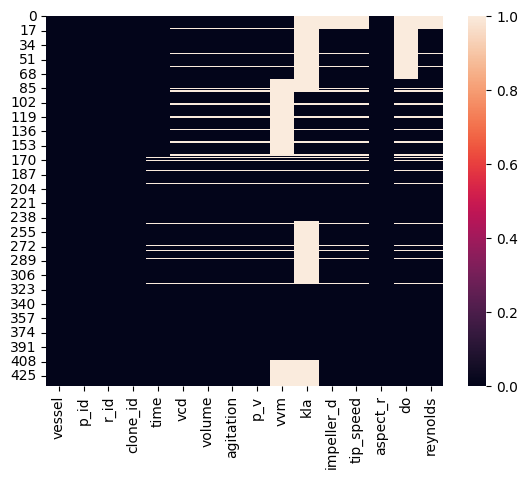

In [ ]:
sns.heatmap(train_df.isnull())

In [ ]:
train_df.isnull().sum()

,0
vessel,0
p_id,0
r_id,0
clone_id,0
time,12
vcd,30
volume,30
agitation,30
p_v,30
vvm,137


In [ ]:
print((437-210)/437*100)

51.94508009153318


kla is missing more than 50% in training data set. I'll drop it.

In [ ]:
train_df = train_df.drop(columns=['kla'])
train_df.head()

,vessel,p_id,r_id,clone_id,time,vcd,volume,agitation,p_v,vvm,impeller_d,tip_speed,aspect_r,do,reynolds
0,ambr 15,1,1,1,0.0,0.41,15.0,1200.0,220.8,0.0,NaN,NaN,1.5,NaN,NaN
1,ambr 15,1,1,1,1.0,2.67,15.0,1200.0,220.8,0.0,NaN,NaN,1.5,NaN,NaN
2,ambr 15,1,1,1,2.0,4.88,15.0,1200.0,220.8,0.0,NaN,NaN,1.5,NaN,NaN
3,ambr 15,1,1,1,3.0,7.09,15.0,1200.0,220.8,0.0,NaN,NaN,1.5,NaN,NaN
4,ambr 15,1,1,1,4.0,11.16,15.0,1200.0,220.8,0.0,NaN,NaN,1.5,NaN,NaN


In [ ]:
test_df = test_df.drop(columns=['kla'])
val_df = val_df.drop(columns=['kla'])
test_df.head()

,vessel,p_id,r_id,clone_id,time,vcd,volume,agitation,p_v,vvm,impeller_d,tip_speed,aspect_r,do,reynolds
0,Ambr 250,3,1,4,0.0016,0.63,0.25,300.0,8.0,0.04,2.6,0.408,2.0,40.0,4794.77
1,Ambr 250,3,1,4,0.9984,0.94,0.25,300.0,8.0,0.04,2.6,0.408,2.0,40.0,4794.77
2,Ambr 250,3,1,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.9,NaN,NaN
3,Ambr 250,3,1,4,2.9942,2.34,0.25,300.0,8.0,0.04,2.6,0.408,2.0,40.0,4794.77
4,Ambr 250,3,1,4,3.9938,3.75,0.25,300.0,8.0,0.04,2.6,0.408,2.0,40.0,4794.77


In [ ]:
val_df.head()

,vessel,p_id,r_id,clone_id,time,vcd,volume,agitation,p_v,vvm,impeller_d,tip_speed,aspect_r,do,reynolds
0,3L glass Sartorius A,4,1,5,0.000000,0.502793,3.0,260.0,13.38,0.0,6.98,0.95,2.0,40.0,29957.82
1,3L glass Sartorius A,4,1,5,1.000000,1.173184,3.0,260.0,13.38,0.0,6.98,0.95,2.0,40.0,29957.82
2,3L glass Sartorius A,4,1,5,1.857143,1.675978,3.0,260.0,13.38,0.0,6.98,0.95,2.0,40.0,29957.82
3,3L glass Sartorius A,4,1,5,3.000000,4.189944,3.0,260.0,13.38,0.0,6.98,0.95,2.0,40.0,29957.82
4,3L glass Sartorius A,4,1,5,3.857143,6.033520,3.0,260.0,13.38,0.0,6.98,0.95,2.0,40.0,29957.82


vessel is just a label. drop it.

DO column records the setpoint (e.g. always 40% or 60% for the run), then it's a process input, not an observed outcome and I don’t want the model to learn to depend on it.

In [ ]:
print(len(train_df), len(val_df), len(test_df))

437 106 120


In [ ]:
train_df = train_df.drop(columns=['vessel'])
test_df = test_df.drop(columns=['vessel'])
val_df = val_df.drop(columns=['vessel'])
train_df.head()

,p_id,r_id,clone_id,time,vcd,volume,agitation,p_v,vvm,impeller_d,tip_speed,aspect_r,do,reynolds
0,1,1,1,0.0,0.41,15.0,1200.0,220.8,0.0,NaN,NaN,1.5,NaN,NaN
1,1,1,1,1.0,2.67,15.0,1200.0,220.8,0.0,NaN,NaN,1.5,NaN,NaN
2,1,1,1,2.0,4.88,15.0,1200.0,220.8,0.0,NaN,NaN,1.5,NaN,NaN
3,1,1,1,3.0,7.09,15.0,1200.0,220.8,0.0,NaN,NaN,1.5,NaN,NaN
4,1,1,1,4.0,11.16,15.0,1200.0,220.8,0.0,NaN,NaN,1.5,NaN,NaN


In [ ]:
train_df = train_df.drop(columns=['do'])
test_df = test_df.drop(columns=['do'])
val_df = val_df.drop(columns=['do'])
train_df.head()

,p_id,r_id,clone_id,time,vcd,volume,agitation,p_v,vvm,impeller_d,tip_speed,aspect_r,reynolds
0,1,1,1,0.0,0.41,15.0,1200.0,220.8,0.0,NaN,NaN,1.5,NaN
1,1,1,1,1.0,2.67,15.0,1200.0,220.8,0.0,NaN,NaN,1.5,NaN
2,1,1,1,2.0,4.88,15.0,1200.0,220.8,0.0,NaN,NaN,1.5,NaN
3,1,1,1,3.0,7.09,15.0,1200.0,220.8,0.0,NaN,NaN,1.5,NaN
4,1,1,1,4.0,11.16,15.0,1200.0,220.8,0.0,NaN,NaN,1.5,NaN


There are missing rows for time	12
vcd	30
volume	30
agitation	30. I'ts small amount, I'll drop them.

In [ ]:
train_df = train_df.dropna(subset=['vcd']).reset_index(drop=True)
val_df = val_df.dropna(subset=['vcd']).reset_index(drop=True)
test_df = test_df.dropna(subset=['vcd']).reset_index(drop=True)

In [ ]:
train_df.isnull().sum()

,0
p_id,0
r_id,0
clone_id,0
time,0
vcd,0
volume,0
agitation,0
p_v,0
vvm,107
impeller_d,14


The impeller diameter is scale-dependent and specific to the vessel. It doesn't make sense to impute it with an average or median value across different scales, because that would introduce misleading information. Given that there are only 14 missing values (a small fraction of the data), I’ll remove these rows entirely instead of trying to impute them.

In [ ]:
train_df = train_df.dropna(subset=['impeller_d']).reset_index(drop=True)


In [ ]:
test_df.isnull().sum()

,0
p_id,0
r_id,0
clone_id,0
time,0
vcd,0
volume,0
agitation,0
p_v,0
vvm,0
impeller_d,0


In [ ]:
val_df.isnull().sum()

,0
p_id,0
r_id,0
clone_id,0
time,1
vcd,0
volume,2
agitation,2
p_v,2
vvm,2
impeller_d,2


In [ ]:
val_df = val_df.dropna(subset=['impeller_d']).reset_index(drop=True)

In [ ]:
val_df.isnull().sum()

,0
p_id,0
r_id,0
clone_id,0
time,1
vcd,0
volume,0
agitation,0
p_v,0
vvm,0
impeller_d,0


In [ ]:
print(len(train_df), len(val_df), len(test_df))

393 94 113


In [ ]:
nan_val = val_df[val_df['time'].isna()].groupby('p_id').size()
print(nan_val)

p_id
4    1
dtype: int64


In [ ]:
nan_val = val_df[val_df['time'].isna()]
print(nan_val)

    p_id  r_id  clone_id  time     vcd  volume  agitation    p_v    vvm  \
73     4     1         8   NaN  13.125   200.0      140.0  38.23  0.005   

    impeller_d  tip_speed  aspect_r   reynolds  
73        22.1       1.62       1.5  161660.79  


In [ ]:
print(val_df[(val_df['p_id'] == 4) & (val_df['clone_id'] == 8)])

    p_id  r_id  clone_id     time        vcd  volume  agitation    p_v    vvm  \
41     4     1         8   0.0000   0.625000     3.0      260.0  13.38  0.000   
42     4     1         8   0.8025   1.041667     3.0      260.0  13.38  0.000   
43     4     1         8   2.7643   2.916667     3.0      260.0  13.38  0.000   
44     4     1         8   3.9236   5.416667     3.0      260.0  13.38  0.000   
45     4     1         8   4.9045   7.708333     3.0      260.0  13.38  0.000   
46     4     1         8   5.8854  10.000000     3.0      260.0  13.38  0.000   
47     4     1         8   6.8662  13.125000     3.0      260.0  13.38  0.000   
48     4     1         8   9.0064  12.916667     3.0      260.0  13.38  0.000   
49     4     1         8  10.8790  10.833333     3.0      260.0  13.38  0.000   
50     4     1         8  11.9490   9.166667     3.0      260.0  13.38  0.000   
51     4     1         8  12.9299   8.750000     3.0      260.0  13.38  0.000   
52     4     1         8  13

It looks like the row is duplicated w/o time point. I'll drop this one.

In [ ]:
val_df = val_df.dropna(subset=['time']).reset_index(drop=True)

In [ ]:
val_df.isnull().sum()

,0
p_id,0
r_id,0
clone_id,0
time,0
vcd,0
volume,0
agitation,0
p_v,0
vvm,0
impeller_d,0


In [ ]:
train_df.isnull().sum()

,0
p_id,0
r_id,0
clone_id,0
time,0
vcd,0
volume,0
agitation,0
p_v,0
vvm,107
impeller_d,0


<Axes: xlabel='p_id', ylabel='vvm'>

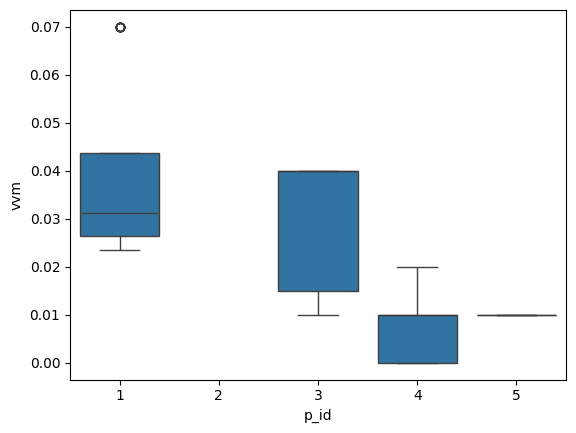

In [ ]:
sns.boxplot(x='p_id', y='vvm', data=train_df)

In [ ]:
train_df.groupby('p_id')['vvm'].median()

,vvm
p_id,
1,0.03125
2,NaN
3,0.04000
4,0.01000
5,0.01000


VVM values are consistently very low across processes, typically ranging from 0.01 to 0.04. Process 2 has no measured VVM (all missing). For imputation, process-specific medians will be used where available, while for Process 2 a global median will be used given the consistent low range across the dataset.

In [ ]:
train_df.groupby('p_id')['vvm'].mean()

,vvm
p_id,
1,0.039000
2,NaN
3,0.027500
4,0.008088
5,0.010000


P1: median = 0,03, while mean = 0,04.

P2 NaN

P3: median = 0,04, mean = 0,03

P4: median = 0,01, mean =0,01

P5: median = 0,01, mean = 0,01.

For imputation, process-specific medians will be used where available, while for Process 2 a global median will be used given the consistent low range across the dataset.

In [ ]:
train_df.loc[(train_df['p_id'] == 1) & (train_df['vvm'].isna()), 'vvm'] = 0.03
train_df.loc[(train_df['p_id'] == 3) & (train_df['vvm'].isna()), 'vvm'] = 0.04
train_df.loc[(train_df['p_id'] == 4) & (train_df['vvm'].isna()), 'vvm'] = 0.01
train_df.loc[(train_df['p_id'] == 5) & (train_df['vvm'].isna()), 'vvm'] = 0.01

In [ ]:
train_df['vvm'].mean()

np.float64(0.01871518987341772)

In [ ]:
train_df['vvm'].median()

0.01

In [ ]:
train_df.loc[(train_df['p_id'] == 2) & (train_df['vvm'].isna()), 'vvm'] = 0.01

In [ ]:
train_df.groupby('p_id')['vvm'].apply(lambda x: x.isnull().sum())

,vvm
p_id,
1,0
2,0
3,0
4,0
5,0


Data has no Nan anymore. Now **timeseries** in a new file.



In [ ]:
print(len(train_df), len(val_df), len(test_df))

393 93 113


In [ ]:
train_df.to_csv('train_df.csv', index=False)
val_df.to_csv('val_df.csv', index=False)
test_df.to_csv('test_df.csv', index=False)

In [ ]:
files.download('train_df.csv')
files.download('val_df.csv')
files.download('test_df.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>